In [1]:
# Change Runtime to T4 GPU

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, \
                                    Conv2D, MaxPooling2D, Input, Dropout, \
                                    BatchNormalization
from tensorflow.keras.datasets import fashion_mnist as fm

In [7]:
type(fm)

module

In [7]:
(xtrain,ytrain), (xtest,ytest) = fm.load_data()
xtrain.shape, ytrain.shape, xtest.shape, ytest.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [9]:
ytrain.shape, ytrain

((60000,), array([9, 0, 0, ..., 3, 0, 5], dtype=uint8))

In [10]:
ytrain.max(), ytrain.min()

(np.uint8(9), np.uint8(0))

In [11]:
labels = ["T-shirt/top"	,"Trouser"	,"Pullover"	,"Dress"	,"Coat"	,"Sandal"	,"Shirt"	,"Sneaker"\
          ,"Bag"	,"Ankleboot" ]


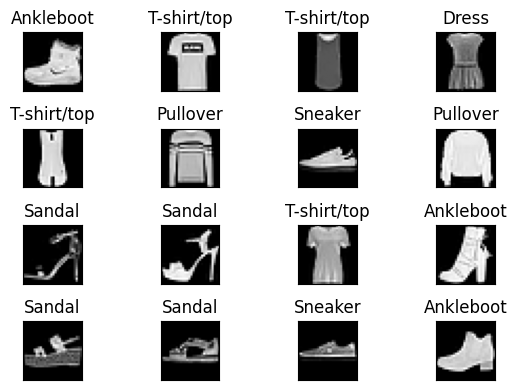

In [12]:
f , ax = plt.subplots(4,4,figsize=(6,4), )
for i, v in enumerate(xtrain[:16]):

  ax[i // 4, i%4].imshow(v, cmap='gray')
  ax[i // 4, i%4].set_title(labels[ytrain[i]])

  ax[i//4, i%4].set_xticks([])
  ax[i//4, i%4].set_yticks([])
plt.tight_layout()

In [13]:
model = Sequential()
model.add(Input(shape=(28,28,1))) # Corrected: changed 'input_shape' to 'shape'
model.add(Conv2D(32, (3,3)))

model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3)))

model.add(MaxPooling2D((2,2)))
model.add(Flatten())

model.add(Dense(10, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
xtrain.reshape(-1, 28, 28, 1)
xtrain.shape

(60000, 28, 28)

In [15]:
xtest.reshape(-1,28,28,1)
xtest.shape

(10000, 28, 28)

In [16]:
model.fit(xtrain,ytrain, batch_size=64, epochs=2, validation_split=0.2)

Epoch 1/2
676/750 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7127 - loss: 5.0321

KeyboardInterrupt: 

In [ ]:
# to increease the accuracy, added 1 more convolution layer

In [ ]:
model = Sequential()
model.add(Input(shape=(28,28,1))) # Corrected: changed 'input_shape' to 'shape'
model.add(Conv2D(32, (3,3)))
model.add(Conv2D(64, (3,3)))

model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128, (3,3)))

model.add(MaxPooling2D((2,2)))
model.add(Flatten())

model.add(Dense(10, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

In [ ]:
xtrain.reshape(-1, 28, 28, 1)
xtest.reshape(-1,28,28,1)

model.fit(xtrain,ytrain, batch_size=64, epochs=10, validation_split=0.2)

In [ ]:
# adding more layers is not improving the accuracy that much.

In [ ]:
# if we add dense layer with 400 nodes with activation fn relu...
model = Sequential()
model.add(Input(shape=(28,28,1))) # Corrected: changed 'input_shape' to 'shape'
model.add(Conv2D(32, (3,3)))


model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3)))

model.add(MaxPooling2D((2,2)))
model.add(Flatten())

model.add(Dense(400, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

In [ ]:
xtrain.reshape(-1, 28, 28, 1)
xtest.reshape(-1,28,28,1)

model.fit(xtrain,ytrain, batch_size=64, epochs=10, validation_split=0.2)

In [ ]:
# accuracy is increased but it could be because of an extra dense layer

In [ ]:
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(32, (3,3)))
model.add(BatchNormalization()) # added batchnormalization


model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3)))


model.add(MaxPooling2D((2,2)))
model.add(Flatten())

model.add(Dense(10, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

In [ ]:
model.fit(xtrain,ytrain, batch_size=128, epochs=10, validation_split=0.2)

In [ ]:
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(32, (3,3)))
model.add(BatchNormalization()) # added batchnormalization


model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3)))
model.add(BatchNormalization()) # added batchnormalization



model.add(MaxPooling2D((2,2)))
model.add(Flatten())

model.add(Dense(10, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

In [ ]:
model.fit(xtrain,ytrain, batch_size=128, epochs=10, validation_split=0.2)

In [3]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, \
                                        Adadelta, Adagrad, Adamax, Nadam

In [12]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.001,
                               decay_steps=10000,
                               decay_rate=0.96)

opt = Adam(learning_rate=lr_schedule)


In [13]:
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(32, (3,3)))
model.add(BatchNormalization()) # added batchnormalization


model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3)))
model.add(BatchNormalization()) # added batchnormalization



model.add(MaxPooling2D((2,2)))
model.add(Flatten())

model.add(Dense(10, activation='softmax'))

model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [14]:
model.fit(xtrain,ytrain, batch_size=128, epochs=10, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7711 - loss: 0.6459 - val_accuracy: 0.8615 - val_loss: 0.3955
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8796 - loss: 0.3422 - val_accuracy: 0.8721 - val_loss: 0.3614
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8913 - loss: 0.3024 - val_accuracy: 0.8802 - val_loss: 0.3332
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9009 - loss: 0.2777 - val_accuracy: 0.8857 - val_loss: 0.3195
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9072 - loss: 0.2544 - val_accuracy: 0.8926 - val_loss: 0.3024
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9141 - loss: 0.2409 - val_accuracy: 0.8910 - val_loss: 0.3173
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9223 - loss: 0.2215 - val_accuracy: 0.8876 - val_loss: 0.3152
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9265 - loss: 0.2081 - val_accuracy: 0.